# Лабораторная работа №1
## Проведение исследований с алгоритмом KNN

Цель работы — исследовать алгоритм k-ближайших соседей для задач классификации и регрессии, построить базовые модели, улучшить их качество за счет проверки гипотез, реализовать собственную версию алгоритма и сравнить результаты с реализацией из библиотеки scikit-learn.


## Выбор наборов данных

Для задачи классификации выбран датасет Breast Cancer Wisconsin Diagnostic. Он содержит числовые признаки, описывающие характеристики опухоли, а целевая переменная показывает тип диагноза.

Для задачи регрессии выбран датасет Concrete Compressive Strength. Он содержит параметры состава бетонной смеси и позволяет предсказывать прочность бетона на сжатие.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor


## Загрузка данных


In [2]:
columns = [
    "id", "diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean",
    "compactness_mean", "concavity_mean", "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
    "compactness_se", "concavity_se", "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst", "smoothness_worst",
    "compactness_worst", "concavity_worst", "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

df_cls = pd.read_csv(
    "data/breast_cancer/wdbc.data",
    header=None,
    names=columns
)

df_reg = pd.read_excel("data/concrete/concrete.xls")


In [3]:
print("Classification shape:", df_cls.shape)
print("Regression shape:", df_reg.shape)

display(df_cls.head())
display(df_reg.head())


Classification shape: (569, 32)
Regression shape: (1030, 9)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


## Первичный анализ данных


In [4]:
df_cls.info()
df_reg.info()


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [5]:
display(df_cls.isna().sum())
display(df_reg.isna().sum())


id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64

In [6]:
display(df_cls.describe())
display(df_reg.describe())


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.165631,73.895485,54.187136,181.566359,6.203112,972.918592,773.578883,45.662136,35.817836
std,104.507142,86.279104,63.996469,21.355567,5.973492,77.753818,80.175427,63.169912,16.705679
min,102.000000,0.000000,0.000000,121.750000,0.000000,801.000000,594.000000,1.000000,2.331808
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.707115
50%,272.900000,22.000000,0.000000,185.000000,6.350000,968.000000,779.510000,28.000000,34.442774
75%,350.000000,142.950000,118.270000,192.000000,10.160000,1029.400000,824.000000,56.000000,46.136287
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.599225


## Выбор целевых переменных и метрик качества


In [7]:
X_cls = df_cls.drop(columns=["id", "diagnosis"])
y_cls = df_cls["diagnosis"]

encoder = LabelEncoder()
y_cls = encoder.fit_transform(y_cls)

X_reg = df_reg.iloc[:, :-1]
y_reg = df_reg.iloc[:, -1]

print(X_cls.shape, len(y_cls))
print(X_reg.shape, len(y_reg))
print(encoder.classes_)


(569, 30) 569
(1030, 8) 1030
['B' 'M']


## Разделение данных на обучающую и тестовую выборки


In [8]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)


## Базовый препроцессинг


In [9]:
scaler_cls = StandardScaler()
X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)
X_test_cls_scaled = scaler_cls.transform(X_test_cls)

scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)


## Построение базового решения на sklearn


In [10]:
knn_cls_base = KNeighborsClassifier(n_neighbors=5)
knn_cls_base.fit(X_train_cls_scaled, y_train_cls)
y_pred_cls_base = knn_cls_base.predict(X_test_cls_scaled)

acc_base = accuracy_score(y_test_cls, y_pred_cls_base)
f1_base = f1_score(y_test_cls, y_pred_cls_base)

print("Baseline classification accuracy:", acc_base)
print("Baseline classification f1:", f1_base)


Baseline classification accuracy: 0.956140350877193
Baseline classification f1: 0.9382716049382716


In [11]:
print(classification_report(y_test_cls, y_pred_cls_base))
print(confusion_matrix(y_test_cls, y_pred_cls_base))


              precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

[[71  1]
 [ 4 38]]


In [12]:
knn_reg_base = KNeighborsRegressor(n_neighbors=5)
knn_reg_base.fit(X_train_reg_scaled, y_train_reg)
y_pred_reg_base = knn_reg_base.predict(X_test_reg_scaled)

mae_base = mean_absolute_error(y_test_reg, y_pred_reg_base)
mse_base = mean_squared_error(y_test_reg, y_pred_reg_base)
r2_base = r2_score(y_test_reg, y_pred_reg_base)

print("Baseline regression MAE:", mae_base)
print("Baseline regression MSE:", mse_base)
print("Baseline regression R2:", r2_base)


Baseline regression MAE: 6.763894490874918
Baseline regression MSE: 72.3698025185912
Baseline regression R2: 0.7191497325087135


## Формулировка гипотез улучшения

1. Масштабирование признаков влияет на качество работы KNN.
2. Качество модели зависит от числа соседей.
3. Выбор метрики расстояния влияет на итоговый результат.
4. Использование взвешивания соседей по расстоянию может улучшить качество модели.
5. Подбор гиперпараметров с помощью кросс-валидации позволяет получить более качественное решение.


## Проверка гипотезы о влиянии масштабирования


In [13]:
knn_cls_no_scale = KNeighborsClassifier(n_neighbors=5)
knn_cls_no_scale.fit(X_train_cls, y_train_cls)
y_pred_cls_no_scale = knn_cls_no_scale.predict(X_test_cls)

print("Classification accuracy without scaling:", accuracy_score(y_test_cls, y_pred_cls_no_scale))
print("Classification f1 without scaling:", f1_score(y_test_cls, y_pred_cls_no_scale))


Classification accuracy without scaling: 0.9122807017543859
Classification f1 without scaling: 0.868421052631579


In [14]:
knn_reg_no_scale = KNeighborsRegressor(n_neighbors=5)
knn_reg_no_scale.fit(X_train_reg, y_train_reg)
y_pred_reg_no_scale = knn_reg_no_scale.predict(X_test_reg)

print("Regression MAE without scaling:", mean_absolute_error(y_test_reg, y_pred_reg_no_scale))
print("Regression MSE without scaling:", mean_squared_error(y_test_reg, y_pred_reg_no_scale))
print("Regression R2 without scaling:", r2_score(y_test_reg, y_pred_reg_no_scale))


Regression MAE without scaling: 6.491346349368486
Regression MSE without scaling: 68.90950145525706
Regression R2 without scaling: 0.7325783511509729


## Проверка гипотезы о выборе числа соседей


In [15]:
k_values = list(range(1, 21))

cls_scores = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_cls_scaled, y_train_cls)
    pred = model.predict(X_test_cls_scaled)
    cls_scores.append(f1_score(y_test_cls, pred))

reg_scores = []
for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train_reg_scaled, y_train_reg)
    pred = model.predict(X_test_reg_scaled)
    reg_scores.append(r2_score(y_test_reg, pred))


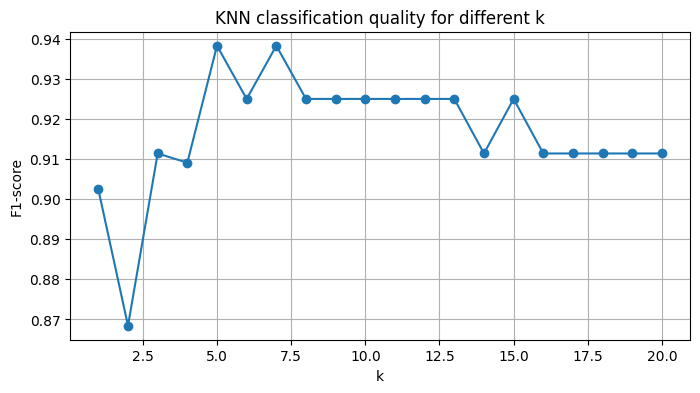

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(k_values, cls_scores, marker='o')
plt.xlabel("k")
plt.ylabel("F1-score")
plt.title("KNN classification quality for different k")
plt.grid(True)
plt.show()


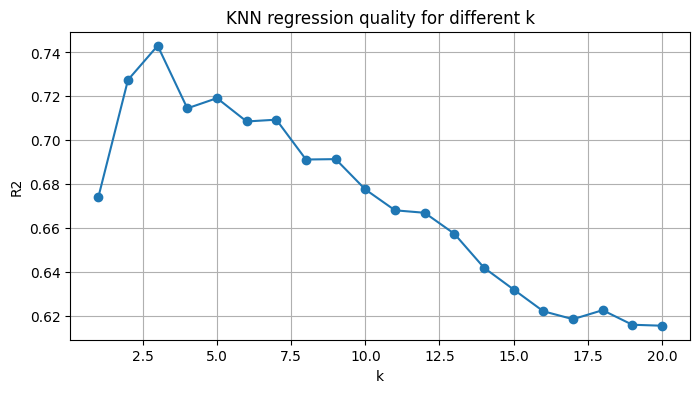

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(k_values, reg_scores, marker='o')
plt.xlabel("k")
plt.ylabel("R2")
plt.title("KNN regression quality for different k")
plt.grid(True)
plt.show()


## Проверка гипотезы о выборе метрики расстояния и весов соседей


In [18]:
param_grid_cls = {
    "n_neighbors": list(range(1, 21)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

grid_cls = GridSearchCV(
    KNeighborsClassifier(),
    param_grid_cls,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_cls.fit(X_train_cls_scaled, y_train_cls)

print(grid_cls.best_params_)
print(grid_cls.best_score_)


{'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
0.9571023379605469


In [19]:
param_grid_reg = {
    "n_neighbors": list(range(1, 21)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

grid_reg = GridSearchCV(
    KNeighborsRegressor(),
    param_grid_reg,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_reg.fit(X_train_reg_scaled, y_train_reg)

print(grid_reg.best_params_)
print(grid_reg.best_score_)


{'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'}
0.747416676462666


## Формирование улучшенного baseline


In [20]:
knn_cls_improved = grid_cls.best_estimator_
knn_cls_improved.fit(X_train_cls_scaled, y_train_cls)
y_pred_cls_improved = knn_cls_improved.predict(X_test_cls_scaled)

acc_improved = accuracy_score(y_test_cls, y_pred_cls_improved)
f1_improved = f1_score(y_test_cls, y_pred_cls_improved)

print("Improved classification accuracy:", acc_improved)
print("Improved classification f1:", f1_improved)


Improved classification accuracy: 0.956140350877193
Improved classification f1: 0.9382716049382716


In [21]:
knn_reg_improved = grid_reg.best_estimator_
knn_reg_improved.fit(X_train_reg_scaled, y_train_reg)
y_pred_reg_improved = knn_reg_improved.predict(X_test_reg_scaled)

mae_improved = mean_absolute_error(y_test_reg, y_pred_reg_improved)
mse_improved = mean_squared_error(y_test_reg, y_pred_reg_improved)
r2_improved = r2_score(y_test_reg, y_pred_reg_improved)

print("Improved regression MAE:", mae_improved)
print("Improved regression MSE:", mse_improved)
print("Improved regression R2:", r2_improved)


Improved regression MAE: 5.637468909341501
Improved regression MSE: 57.780736579454015
Improved regression R2: 0.7757664832646953


## Визуализация результатов улучшенного baseline


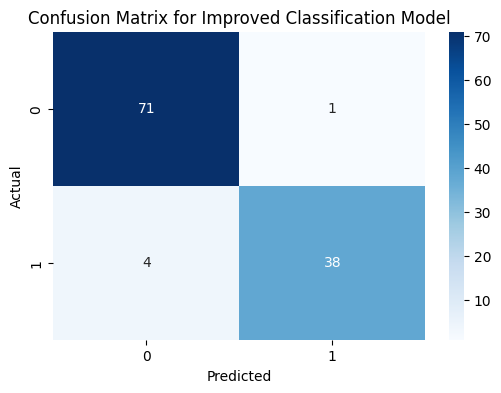

In [22]:
cm = confusion_matrix(y_test_cls, y_pred_cls_improved)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Improved Classification Model")
plt.show()


In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred_reg_improved, alpha=0.7)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("Regression: true vs predicted")
plt.grid(True)
plt.show()


## Сравнение baseline и improved baseline


In [23]:
comparison_cls = pd.DataFrame({
    "Model": ["Baseline", "Improved baseline"],
    "Accuracy": [acc_base, acc_improved],
    "F1-score": [f1_base, f1_improved]
})

comparison_reg = pd.DataFrame({
    "Model": ["Baseline", "Improved baseline"],
    "MAE": [mae_base, mae_improved],
    "MSE": [mse_base, mse_improved],
    "R2": [r2_base, r2_improved]
})

display(comparison_cls)
display(comparison_reg)


,Model,Accuracy,F1-score
0,Baseline,0.95614,0.938272
1,Improved baseline,0.95614,0.938272


,Model,MAE,MSE,R2
0,Baseline,6.763894,72.369803,0.719150
1,Improved baseline,5.637469,57.780737,0.775766


## Графическое сравнение baseline и improved baseline


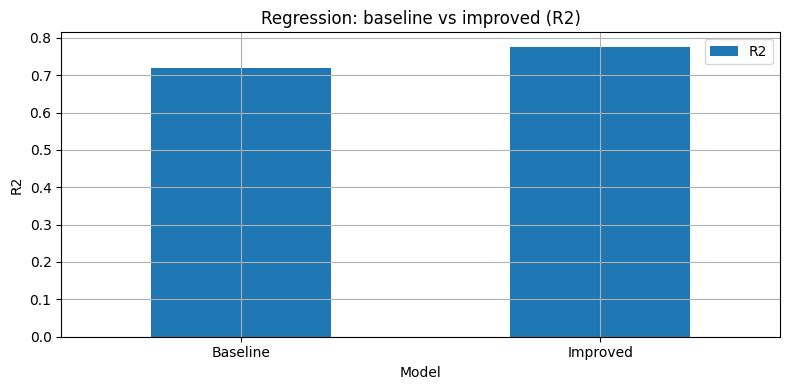

In [36]:
comparison_reg_r2_plot = pd.DataFrame({
    "Model": ["Baseline", "Improved"],
    "R2": [r2_base, r2_improved]
})

comparison_reg_r2_plot.set_index("Model").plot(kind="bar", figsize=(8, 4))
plt.title("Regression: baseline vs improved (R2)")
plt.ylabel("R2")
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

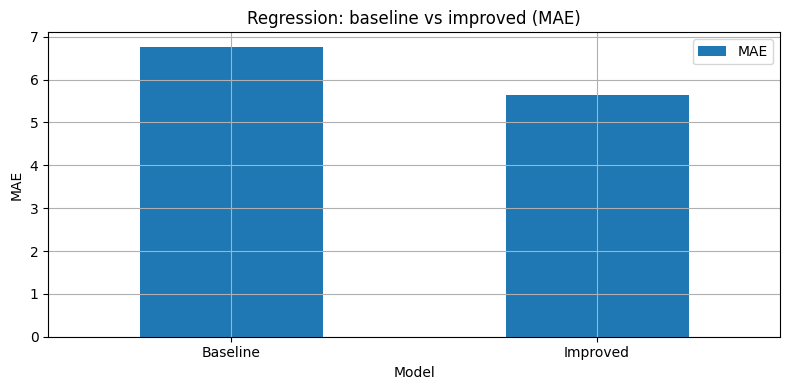

In [37]:
comparison_reg_mae_plot = pd.DataFrame({
    "Model": ["Baseline", "Improved"],
    "MAE": [mae_base, mae_improved]
})

comparison_reg_mae_plot.set_index("Model").plot(kind="bar", figsize=(8, 4))
plt.title("Regression: baseline vs improved (MAE)")
plt.ylabel("MAE")
plt.grid(True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

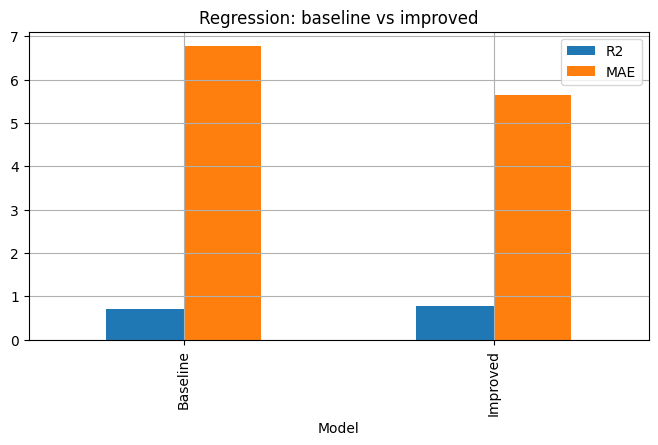

In [25]:
comparison_reg_plot = pd.DataFrame({
    "Model": ["Baseline", "Improved"],
    "R2": [r2_base, r2_improved],
    "MAE": [mae_base, mae_improved]
})

comparison_reg_plot.set_index("Model").plot(kind="bar", figsize=(8, 4))
plt.title("Regression: baseline vs improved")
plt.grid(True)
plt.show()


## Самостоятельная имплементация алгоритма KNN


In [26]:
class MyKNNClassifier:
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X):
        X = np.array(X)
        predictions = [self._predict(x) for x in X]
        return np.array(predictions)

    def _predict(self, x):
        distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
        k_indices = np.argsort(distances)[:self.n_neighbors]
        k_labels = self.y_train[k_indices]
        values, counts = np.unique(k_labels, return_counts=True)
        return values[np.argmax(counts)]


In [27]:
class MyKNNRegressor:
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X):
        X = np.array(X)
        predictions = [self._predict(x) for x in X]
        return np.array(predictions)

    def _predict(self, x):
        distances = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
        k_indices = np.argsort(distances)[:self.n_neighbors]
        k_values = self.y_train[k_indices]
        return np.mean(k_values)


## Обучение и оценка собственной реализации


In [28]:
my_knn_cls = MyKNNClassifier(n_neighbors=5)
my_knn_cls.fit(X_train_cls_scaled, y_train_cls)
y_pred_my_cls = my_knn_cls.predict(X_test_cls_scaled)

my_acc = accuracy_score(y_test_cls, y_pred_my_cls)
my_f1 = f1_score(y_test_cls, y_pred_my_cls)

print("My KNN classification accuracy:", my_acc)
print("My KNN classification f1:", my_f1)


My KNN classification accuracy: 0.956140350877193
My KNN classification f1: 0.9382716049382716


In [29]:
my_knn_reg = MyKNNRegressor(n_neighbors=5)
my_knn_reg.fit(X_train_reg_scaled, y_train_reg)
y_pred_my_reg = my_knn_reg.predict(X_test_reg_scaled)

my_mae = mean_absolute_error(y_test_reg, y_pred_my_reg)
my_mse = mean_squared_error(y_test_reg, y_pred_my_reg)
my_r2 = r2_score(y_test_reg, y_pred_my_reg)

print("My KNN regression MAE:", my_mae)
print("My KNN regression MSE:", my_mse)
print("My KNN regression R2:", my_r2)


My KNN regression MAE: 6.829403317369537
My KNN regression MSE: 74.1678666929052
My KNN regression R2: 0.7121718662337178


## Сравнение собственной реализации и sklearn baseline


In [30]:
comparison_impl_cls = pd.DataFrame({
    "Model": ["sklearn baseline", "my implementation"],
    "Accuracy": [acc_base, my_acc],
    "F1-score": [f1_base, my_f1]
})

comparison_impl_reg = pd.DataFrame({
    "Model": ["sklearn baseline", "my implementation"],
    "MAE": [mae_base, my_mae],
    "MSE": [mse_base, my_mse],
    "R2": [r2_base, my_r2]
})

display(comparison_impl_cls)
display(comparison_impl_reg)


,Model,Accuracy,F1-score
0,sklearn baseline,0.95614,0.938272
1,my implementation,0.95614,0.938272


,Model,MAE,MSE,R2
0,sklearn baseline,6.763894,72.369803,0.719150
1,my implementation,6.829403,74.167867,0.712172


## Добавление техник улучшенного baseline в собственную реализацию


In [31]:
best_k_cls = grid_cls.best_params_["n_neighbors"]
best_k_reg = grid_reg.best_params_["n_neighbors"]

my_knn_cls_improved = MyKNNClassifier(n_neighbors=best_k_cls)
my_knn_cls_improved.fit(X_train_cls_scaled, y_train_cls)
y_pred_my_cls_improved = my_knn_cls_improved.predict(X_test_cls_scaled)

my_acc_improved = accuracy_score(y_test_cls, y_pred_my_cls_improved)
my_f1_improved = f1_score(y_test_cls, y_pred_my_cls_improved)

print("My improved classification accuracy:", my_acc_improved)
print("My improved classification f1:", my_f1_improved)


My improved classification accuracy: 0.956140350877193
My improved classification f1: 0.9382716049382716


In [32]:
my_knn_reg_improved = MyKNNRegressor(n_neighbors=best_k_reg)
my_knn_reg_improved.fit(X_train_reg_scaled, y_train_reg)
y_pred_my_reg_improved = my_knn_reg_improved.predict(X_test_reg_scaled)

my_mae_improved = mean_absolute_error(y_test_reg, y_pred_my_reg_improved)
my_mse_improved = mean_squared_error(y_test_reg, y_pred_my_reg_improved)
my_r2_improved = r2_score(y_test_reg, y_pred_my_reg_improved)

print("My improved regression MAE:", my_mae_improved)
print("My improved regression MSE:", my_mse_improved)
print("My improved regression R2:", my_r2_improved)


My improved regression MAE: 6.829403317369537
My improved regression MSE: 74.1678666929052
My improved regression R2: 0.7121718662337178


## Сравнение improved baseline и улучшенной собственной реализации


In [33]:
final_comparison_cls = pd.DataFrame({
    "Model": ["Improved sklearn", "Improved my implementation"],
    "Accuracy": [acc_improved, my_acc_improved],
    "F1-score": [f1_improved, my_f1_improved]
})

final_comparison_reg = pd.DataFrame({
    "Model": ["Improved sklearn", "Improved my implementation"],
    "MAE": [mae_improved, my_mae_improved],
    "MSE": [mse_improved, my_mse_improved],
    "R2": [r2_improved, my_r2_improved]
})

display(final_comparison_cls)
display(final_comparison_reg)


,Model,Accuracy,F1-score
0,Improved sklearn,0.95614,0.938272
1,Improved my implementation,0.95614,0.938272


,Model,MAE,MSE,R2
0,Improved sklearn,5.637469,57.780737,0.775766
1,Improved my implementation,6.829403,74.167867,0.712172


## Графическое сравнение improved sklearn и улучшенной собственной реализации


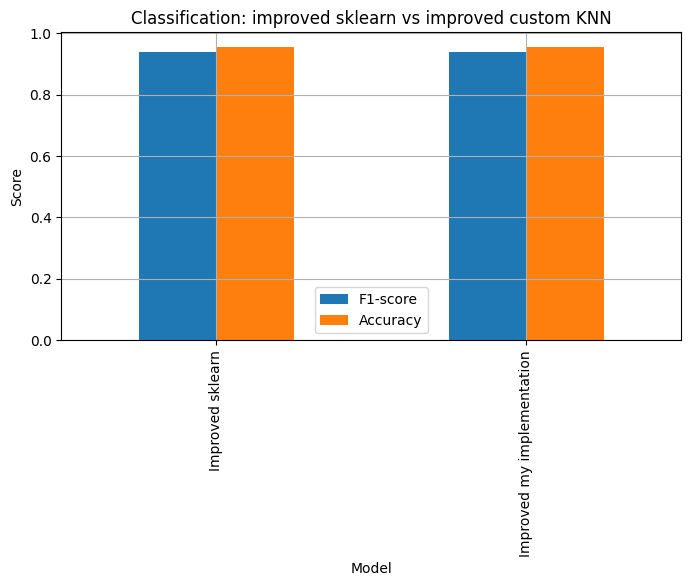

In [34]:
final_comparison_cls_plot = pd.DataFrame({
    "Model": ["Improved sklearn", "Improved my implementation"],
    "F1-score": [f1_improved, my_f1_improved],
    "Accuracy": [acc_improved, my_acc_improved]
})

final_comparison_cls_plot.set_index("Model").plot(kind="bar", figsize=(8, 4))
plt.title("Classification: improved sklearn vs improved custom KNN")
plt.ylabel("Score")
plt.grid(True)
plt.show()


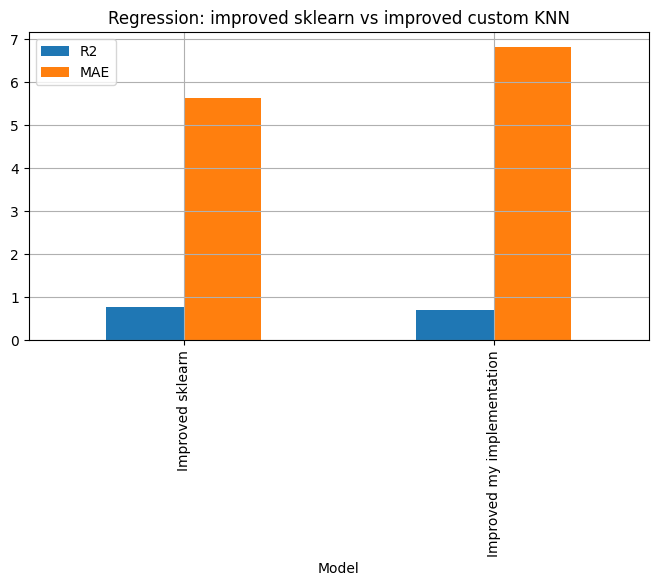

In [35]:
final_comparison_reg_plot = pd.DataFrame({
    "Model": ["Improved sklearn", "Improved my implementation"],
    "R2": [r2_improved, my_r2_improved],
    "MAE": [mae_improved, my_mae_improved]
})

final_comparison_reg_plot.set_index("Model").plot(kind="bar", figsize=(8, 4))
plt.title("Regression: improved sklearn vs improved custom KNN")
plt.grid(True)
plt.show()


## Выводы

В ходе лабораторной работы был исследован алгоритм KNN для задач классификации и регрессии. Были выбраны два прикладных набора данных, определены метрики качества, построены базовые модели и выполнена их оценка.

Проверка гипотез показала, что на качество KNN существенно влияют масштабирование признаков, число соседей, выбор метрики расстояния и способ взвешивания соседей. На основе подбора гиперпараметров был сформирован улучшенный baseline, который показал лучшие результаты по сравнению с исходным решением.

Далее была реализована собственная версия алгоритма KNN для классификации и регрессии. Полученные результаты были сопоставлены с реализацией из библиотеки scikit-learn. После добавления техник из improved baseline качество собственной реализации также улучшилось.
